In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from custom_kfold import CustomKFold
from sdee_statistics import calculate_nmae
from train_dataset import get_X_y, train_model_cv
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import (
    SelectPercentile,
    f_regression,
    mutual_info_regression,
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import mutual_info_regression



In [2]:
# load dataset heads:
dataset_iteration_30 = pd.read_csv("datasets/apache_iteration_30_features.csv")
dataset_iteration_30.head(1)

# setup model:
X, y = get_X_y(dataset_iteration_30)

custom_kfold = CustomKFold(n_splits=10, shuffle=False)

# train model
random_forest = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)

nmae_scorer = make_scorer(calculate_nmae, greater_is_better=False)

In [3]:
#nmae_values = train_model_cv(X, y, random_forest, custom_kfold)
nmae_values = cross_val_score(random_forest, X, y, cv=custom_kfold, scoring=nmae_scorer) 
print(f"Avg nmae: {sum(nmae_values) / len(nmae_values)}")

Avg nmae: -0.3321543077356952


### Feature importances

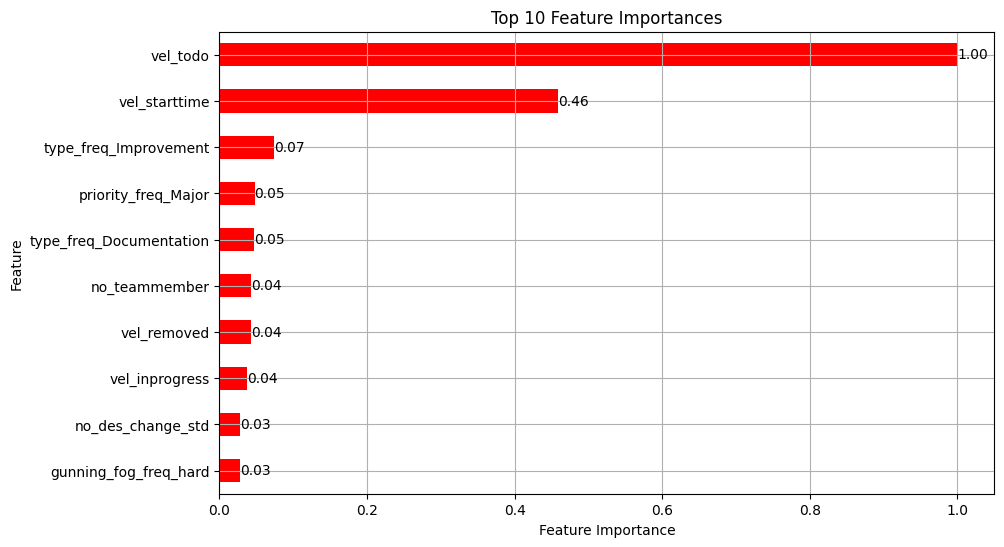

In [4]:
random_forest.fit(X, y)

# get the feature ranking of the rf model:
myClassifiers = pd.Series(random_forest.feature_importances_, index=X.columns)

# Normalize feature importances
scaler = MinMaxScaler()
myClassifiers_normalized = scaler.fit_transform(myClassifiers.values.reshape(-1, 1)).flatten()
myClassifiers_normalized = pd.Series(myClassifiers_normalized, index=myClassifiers.index)

# Sort the Series by importance in descending order
myClassifiers_normalized = myClassifiers_normalized.sort_values(ascending=False)

# Plot only the top 10 most relevant features
top_n = 10
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances")
myClassifiers_normalized[:top_n].plot(kind='barh', color='r')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.grid()
plt.gca().invert_yaxis()  # Invert y-axis to have the most relevant feature at the top
# Annotate each bar with its value
for i, value in enumerate(myClassifiers_normalized[:top_n]):
    plt.text(value, i, f'{value:.2f}', ha='left', va='center')
plt.show()


### Try if reduced Features subset reduces NMAE

In [7]:
X, y = get_X_y(dataset_iteration_30)


class CustomFeatureImportancesSelector(object):
    def __init__(self, percentile: int, feature_importances: list[float]):
        self.percentile = percentile
        self.feature_importances = feature_importances.sort_values(ascending=False)

    def transform(self, X):
        # Calculate the number of columns to select based on percentile
        num_cols = int(np.ceil(self.percentile / 100 * len(self.feature_importances)))
        # Select top columns based on percentile
        selected_columns = [col for col in self.feature_importances[:num_cols].index]
        # Extract selected columns from the input array X
        cols = X[selected_columns]
        return cols

    def fit(self, X, y=None):
        return self


percentiles = [20, 40, 60, 100]
for percentile in percentiles:
    print(f"Training model for {percentile}% of the features:")
    pipeline = Pipeline(
        [
            (
                "feature_selection",
                CustomFeatureImportancesSelector(
                    percentile=percentile, feature_importances=myClassifiers
                ),
                # SelectPercentile(percentile=percentile, score_func=custom_score_func),
            ),
            ("regression", random_forest),
        ]
    )

    nmae_values = cross_val_score(pipeline, X, y, cv=custom_kfold, scoring=nmae_scorer)
    print(f"avg nmae: {sum(nmae_values) / len(nmae_values)}")
    print("=" * 40)

Training model for 20% of the features:
avg nmae: -0.3263227398477945
Training model for 40% of the features:
avg nmae: -0.32584322367522106
Training model for 60% of the features:
avg nmae: -0.3312656998176723
Training model for 100% of the features:
avg nmae: -0.3317182390447943


### Sequential Forward Search

In [ ]:
sfs = SequentialFeatureSelector(
    random_forest,
    cv=custom_kfold,
    scoring=make_scorer(calculate_nmae, greater_is_better=False),
)

sfs.fit(X, y)
print(sfs.get_support())